In [41]:
import numpy as np
import emcee 
import h5py
import matplotlib.pyplot as plt
import corner
import ocmscripts.plots.shared as shared

In [42]:
from lymph import types
from lyscripts import utils
from lyscripts.configs import ModelConfig, GraphConfig, DistributionConfig, construct_model, add_distributions
import ocmscripts.config as config

def get_model(
    which: str,
    load_samples: bool = True,
) -> types.Model:
    params_path = config.CONFIGS_DIR / "graphs" / f"{which}.ly.yaml"
    params = utils.load_yaml_params(params_path)
    model_config = ModelConfig(**params['model'])
    graph_config = GraphConfig(**params['graph'])
    distributions = {}
    for key, item in params['distributions'].items():
        dist_config = DistributionConfig(**item)
        distributions[key] = dist_config

    model = construct_model(model_config, graph_config)
    model = add_distributions(model, distributions)

    if not load_samples:
        return model
    
    samples_path = config.SAMPLES_DIR / f"{which}.hdf5"
    samples = utils.load_model_samples(samples_path)
    model.set_params(*samples.mean(axis=0))

    return model

In [43]:
COLORS = {
    "blue": "#005ea8",
    "orange": "#f17900",
    "green": "#00afa5",
    "red": "#ae0060",
    "gray": "#c5d5db",
}

In [27]:
model = get_model('midline+II_I+III_V')

In [29]:
model.get_params()

{'ipsi_TtoI_spread': np.float64(0.05043780787702102),
 'ipsi_TtoII_spread': np.float64(0.08973666967765458),
 'ipsi_TtoIII_spread': np.float64(0.02004182084082146),
 'ipsi_TtoIV_spread': np.float64(0.007093570089523854),
 'ipsi_TtoV_spread': np.float64(0.006287850267851769),
 'contra_TtoI_spread': np.float64(0.008884927915068305),
 'contra_TtoII_spread': np.float64(0.008362117111050484),
 'contra_TtoIII_spread': np.float64(0.004613126935611822),
 'contra_TtoIV_spread': np.float64(0.00405747822924046),
 'contra_TtoV_spread': np.float64(0.003273364278057429),
 'mixing': np.float64(0.6516398931741978),
 'IItoI_spread': np.float64(0.14840313473611885),
 'IItoIII_spread': np.float64(0.12007604863662114),
 'IIItoIV_spread': np.float64(0.09767714644965338),
 'IIItoV_spread': np.float64(0.08884143803903649),
 'late_p': np.float64(0.5157695358196515),
 'midext_prob': np.float64(0.07421558474817114)}

In [30]:
file_path = 'models/samples/midline+II_I+III_V.hdf5'
#file_path = 'models/samples/base+II_I+III_V+IV_V_integration.hdf5'
backend = emcee.backends.HDFBackend(file_path, name='mcmc', read_only=True)
samples = backend.get_chain(flat=False, discard=0, thin=1)

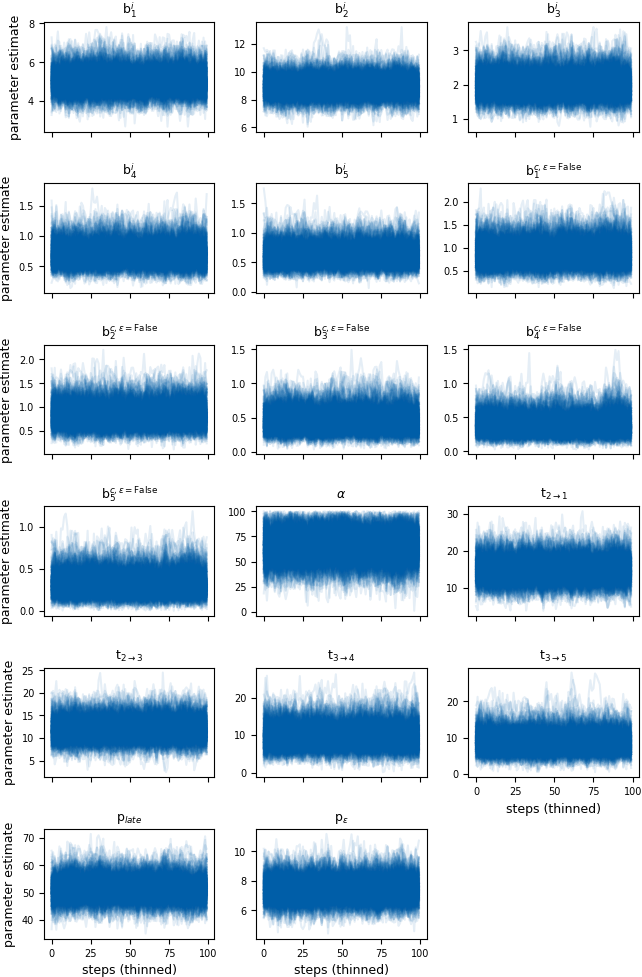

In [51]:
nrows, ncols = 6, 3
plt.rcParams.update(shared.get_fontsizes(base = 9))
plt.rcParams.update(
    shared.get_figsizes(
        nrows=nrows,
        ncols=ncols,
        aspect_ratio=4.0,
        width=17,
        constrained_layout=True,
        tight_layout=True,
    )
)

labels = ['b$_1^{i}$', 'b$_2^{i}$', 'b$_3^{i}$', 'b$_4^{i}$', 'b$_5^{i}$',r'b$_1^{c, \epsilon = \text{False}}$', r'b$_2^{c , \epsilon = \text{False}}$', r'b$_3^{c, \epsilon = \text{False}}$', r'b$_4^{c, \epsilon = \text{False}}$', r'b$_5^{c, \epsilon = \text{False}}$', r'$\alpha$', r't$_{2\rightarrow1}$', r't$_{2\rightarrow3}$', r't$_{3\rightarrow4}$', r't$_{3\rightarrow5}$', 'p$_{late}$', r'p$_{\epsilon}$']

#fig, axes = plt.subplots(6, 3, figsize=(16, 16), sharex=True)
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(17*shared.CM_TO_INCH, 17*shared.CM_TO_INCH/4.0*nrows), sharex=True)

rows, cols = axes.shape

for i in range(17):
    row, col = divmod(i, cols)
    axis = axes[row, col]
    axis.plot(samples[:, :, i] * 100, color=COLORS['blue'], alpha=0.1)
    axis.set_title(labels[i])

    if col == 0:
        axis.set_ylabel('parameter estimate')
    else:
        axis.set_ylabel('')
        #axis.tick_params(labelleft=False)

    show_bottom_axis = (row == rows - 1 and col < cols - 1) or (row == rows - 2 and col == cols - 1)
    if show_bottom_axis:
        axis.set_xlabel('steps (thinned)')
        axis.tick_params(labelbottom=True)
    else:
        axis.set_xlabel('')
        axis.tick_params(labelbottom=False)

fig.delaxes(axes[-1, -1])
plt.tight_layout()
plt.savefig('reports/figures/mcmc_traceplots.pdf', bbox_inches='tight')
plt.show()

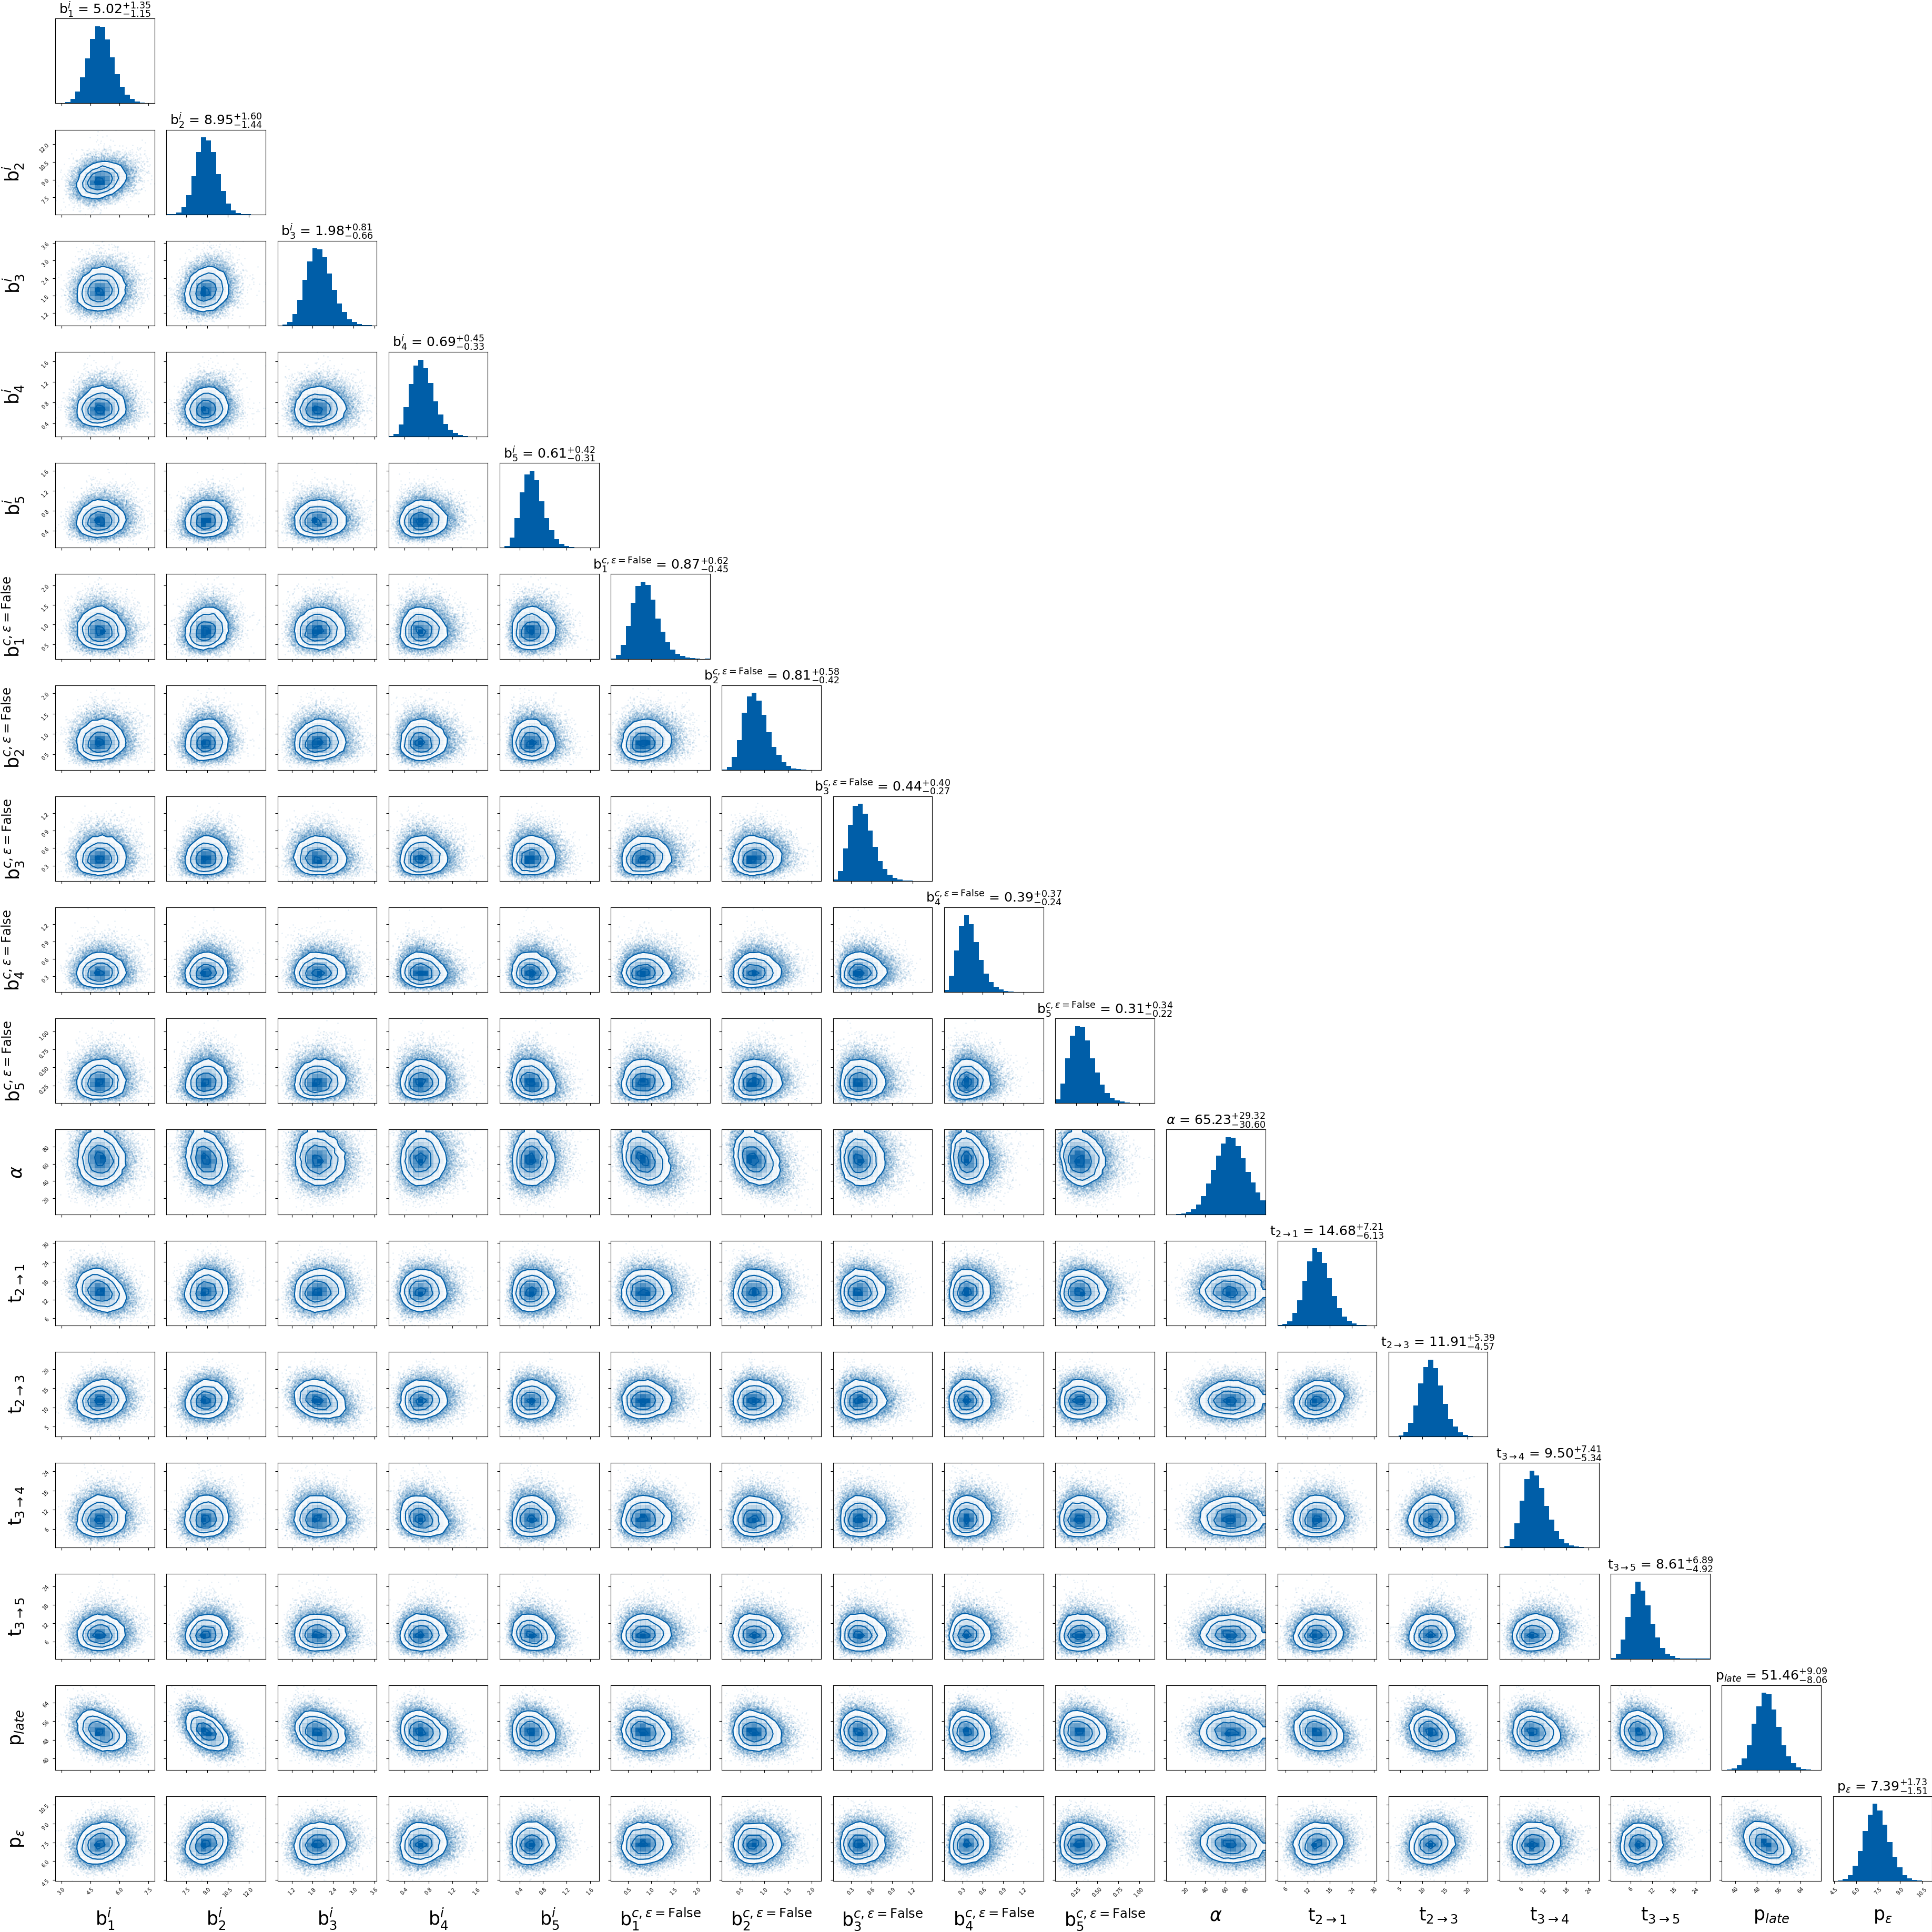

In [55]:
#fig = corner.corner(samples.reshape(-1, 17))
figure = corner.corner(samples.reshape(-1, 17)*100, titles = labels, color = COLORS['blue'], hist_kwargs={'histtype':'bar'}, title_quantiles=[0.025, 0.5, 0.975], show_titles = True, labels = labels, label_kwargs={'fontsize': 25}, title_kwargs={'fontsize': 18})
figure.savefig('reports/figures/mcmc_cornerplot.pdf', bbox_inches='tight')